In [1]:
import xarray as xr
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from datetime import timedelta
from timeit import default_timer
import xhistogram.xarray as xhx
import seaborn as sns
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 14
})
import matplotlib.colors as colors




In [2]:
dummy = xr.open_mfdataset("/pscratch/sd/a/amahesh/hens/demo_bred_1step/ensemble_out_0000*_2020-06-18-00-00-00.nc",
                     group='global', concat_dim='ensemble', combine='nested')

In [12]:
def load_hens_min_mse(curr_date, curr_date_idx):
    stats_ds = xr.open_dataset(f"/pscratch/sd/a/amahesh/hens_h5/stats/t2m_{curr_date:%Y%m%d}_reduced-lead-04-07-10.h5")
    stats_ds = stats_ds.rename({"phony_dim_4" : 'ensemble_size',
                    "phony_dim_2" : 'lat',
                     "phony_dim_3" : 'lon',
                     'phony_dim_1' : 'time'})
    stats_ds['lat'] = dummy['lat']
    stats_ds['lon'] = dummy['lon']
    # Select 10 day lead time
    return stats_ds['t2m_min_mse_bootstrap_mean'].isel(phony_dim_0=curr_date_idx)
def load_hens_min_mse_interval(curr_date, curr_date_idx):
    stats_ds = xr.open_dataset(f"/pscratch/sd/a/amahesh/hens_h5/stats/t2m_{curr_date:%Y%m%d}_reduced-lead-04-07-10.h5")
    stats_ds = stats_ds.rename({"phony_dim_4" : 'ensemble_size',
                "phony_dim_2" : 'lat',
                 "phony_dim_3" : 'lon',
                 'phony_dim_1' : 'time',
                 'phony_dim_5' : 'interval'})
    stats_ds['lat'] = dummy['lat']
    stats_ds['lon'] = dummy['lon']
    return stats_ds['t2m_min_mse_interval'].isel(phony_dim_0=curr_date_idx)

def load_ifs(ifs_ds, curr_date):
    ifs = ifs_ds.sel(time=f"{curr_date:%Y-%m-%d}", drop=True).rename({'latitude' : 'lat', 
                                                      'longitude' : 'lon'})
    ifs = ifs.sel(step=slice(np.timedelta64(10, 'D'),np.timedelta64(258, 'h')))
    return ifs['t2m'].values
    
def load_analysis(curr_date):
    valid_date = curr_date + timedelta(days=10)
    print(valid_date)
    analysis = xr.open_dataset(f"/pscratch/sd/a/amahesh/tigge/analysis/ifs_analysis-2023-{valid_date.month:02d}.grib")
    true_t2m = analysis['t2m'].sel(time=f"{valid_date:%Y-%m-%d}").rename({'latitude' : 'lat', 
                                                  'longitude' : 'lon'})
    return true_t2m.load()

def load_era5(curr_date):
    valid_date = curr_date + timedelta(days=4)
    print(valid_date)
    true = xr.open_dataset("/pscratch/sd/p/pharring/74var-6hourly/staging/2023.h5", mode='r')
    true = true.rename({'phony_dim_0' : 'time',
                        'phony_dim_2' : 'lat', 
                 'phony_dim_3' : 'lon',
                 'phony_dim_1' : 'channel'})
    true['lat'] = dummy['lat']
    true['lon'] = dummy['lon']
    true['channel'] = ["u10m", "v10m", "u100m", "v100m", "t2m", "sp", "msl", "tcwv", "2d", "u50", "u100", "u150", "u200", "u250", "u300", "u400", "u500", "u600", "u700", "u850", "u925", "u1000", "v50", "v100", "v150", "v200", "v250", "v300", "v400", "v500", "v600", "v700", "v850", "v925", "v1000", "z50", "z100", "z150", "z200", "z250", "z300", "z400", "z500", "z600", "z700", "z850", "z925", "z1000", "t50", "t100", "t150", "t200", "t250", "t300", "t400", "t500", "t600", "t700", "t850", "t925", "t1000", "q50", "q100", "q150", "q200", "q250", "q300", "q400", "q500", "q600", "q700", "q850", "q925", "q1000"]
    true['time'] = pd.date_range("2023-01-01", periods=1460, freq='6H')

    true = true.sel(time=f"{valid_date:%Y-%m-%d}")
    true_t2m = true['fields'].sel(channel='t2m')
    return true_t2m

def load_mu_sigma(curr_date):
    valid_date = curr_date + timedelta(days=4)
    print(valid_date)
    mu, sigma = [],[]
    for hour in [0,6,12,18]:
        mu.append(xr.open_zarr(f"/pscratch/sd/a/amahesh/hens/thresholds/t2m_mean_{valid_date.month:02d}_{hour:02d}/").rename({'VAR_2T' : 't2m',
                        'latitude' : 'lat', 
                        'longitude' : 'lon'}))
        sigma.append(xr.open_zarr(f"/pscratch/sd/a/amahesh/hens/thresholds/t2m_std_{valid_date.month:02d}_{hour:02d}/").rename({'VAR_2T' : 't2m',
                        'latitude' : 'lat', 
                        'longitude' : 'lon'}))
    mu = xr.concat(mu, dim='time')
    sigma = xr.concat(sigma, dim='time')
    return mu['t2m'], sigma['t2m']

In [8]:
def group_by_leadtime_by_size(hens_min_mse):
    lat_rad = np.deg2rad(hens_min_mse['lat'])
    weights = np.cos(lat_rad)

    # Initialize an empty list to store the results
    results = []

    # Loop over lead_time and ensemble_size
    for lead_time in hens_min_mse['time']:
        current=[]
        for ensemble in hens_min_mse['ensemble_size']:
            # Select the data for the current lead_time and ensemble_size
            data = hens_min_mse.sel(time=lead_time, ensemble_size=ensemble)

            # Calculate the weighted mean
            weighted_mean = data.weighted(weights).mean(('lat', 'lon'))
            # Assign lead_time and ensemble_size as coordinates
            weighted_mean = weighted_mean.expand_dims({'lead_time': [lead_time], 'ensemble_size': [ensemble]})
            current.append(weighted_mean)

            # Append the result to the list
        results.append(current)

    # Concatenate all the results into a single DataArray
    return xr.combine_nested(results, concat_dim=['lead_time', 'ensemble_size'])

In [13]:
dates = pd.date_range('2023-06-01', '2023-08-31', freq='D')
all_min_mse_interval = []
for idx, curr_date in enumerate(dates):    
    start = default_timer()
    hens_min_mse = load_hens_min_mse_interval(curr_date, idx)
    #0,1,2,3 correspond to day 4
    all_min_mse_interval.append(hens_min_mse.isel(time=[0,1,2,3]))
    print('finished in ', default_timer() - start)
   
   



finished in  0.009000051068142056
finished in  0.00759276794269681
finished in  0.007368945050984621
finished in  0.007733781123533845
finished in  0.007406997960060835
finished in  0.00735808489844203
finished in  0.007506991969421506
finished in  0.0073604590725153685
finished in  0.007461512926965952
finished in  0.007367202080786228
finished in  0.007435312960296869
finished in  0.007423170143738389
finished in  0.007428179029375315
finished in  0.007548983907327056
finished in  0.008311768993735313
finished in  0.00818864000029862
finished in  0.008247955003753304
finished in  0.008355633122846484
finished in  0.008377325953915715
finished in  0.008271730970591307
finished in  0.007539686048403382
finished in  0.007304931990802288
finished in  0.007377411006018519
finished in  0.007675016997382045
finished in  0.007601283956319094
finished in  0.007657163077965379
finished in  0.008032830199226737
finished in  0.007977461908012629
finished in  0.008279416942968965
finished in  0.0

In [14]:
dates = pd.date_range('2023-06-01', '2023-08-31', freq='D')
all_era5_zscore = []
for idx, curr_date in enumerate(dates):
    start = default_timer()
    
    era5 = load_era5(curr_date)
    
    mu, sigma = load_mu_sigma(curr_date)
    
    era5_zscore = (era5 - mu)/sigma
    all_era5_zscore.append(era5_zscore.load().reset_index('time'))
    print('finished in ', default_timer() - start)
   
   



2023-06-05 00:00:00
2023-06-05 00:00:00


/tmp/ipykernel_1928368/3964813958.py:47: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  true['time'] = pd.date_range("2023-01-01", periods=1460, freq='6H')


finished in  9.872941695852205
2023-06-06 00:00:00
2023-06-06 00:00:00


/tmp/ipykernel_1928368/3964813958.py:47: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  true['time'] = pd.date_range("2023-01-01", periods=1460, freq='6H')


finished in  9.95848167478107
2023-06-07 00:00:00
2023-06-07 00:00:00


...

finished in  9.581986262928694
2023-09-03 00:00:00
2023-09-03 00:00:00


/tmp/ipykernel_1928368/3964813958.py:47: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  true['time'] = pd.date_range("2023-01-01", periods=1460, freq='6H')


finished in  9.926194353029132
2023-09-04 00:00:00
2023-09-04 00:00:00


/tmp/ipykernel_1928368/3964813958.py:47: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  true['time'] = pd.date_range("2023-01-01", periods=1460, freq='6H')


finished in  9.567693665856495


In [15]:
all_era5_zscore = xr.concat(all_era5_zscore, dim='initial_time')

In [17]:
all_min_mse_interval = xr.concat(all_min_mse_interval, dim='initial_time')

In [18]:
all_min_mse_interval.to_zarr("/pscratch/sd/a/amahesh/temp/all_min_mse_interval_lead4day.zarr")

In [19]:
all_era5_zscore.to_zarr("/pscratch/sd/a/amahesh/temp/all_era5_zscore_lead4day.zarr")


In [20]:
dates = pd.date_range('2023-06-01', '2023-08-31', freq='D')
all_min_mse, global_mean_min_mse = [], []
for idx, curr_date in enumerate(dates):
    start = default_timer()
    hens_min_mse = load_hens_min_mse(curr_date, idx)
    all_min_mse.append(hens_min_mse.isel(time=[0,1,2,3]))
    print('finished in ', default_timer() - start)
   

finished in  0.011060441844165325
finished in  0.007757955929264426
finished in  0.007404582109302282
finished in  0.007175818085670471
finished in  0.009706074139103293
finished in  0.0073476911056786776
finished in  0.007598226889967918
finished in  0.007475509075447917
finished in  0.009541444946080446
finished in  0.007222609128803015
finished in  0.007178995059803128
finished in  0.0069825248792767525
finished in  0.007067480124533176
finished in  0.0068730630446225405
finished in  0.007533511146903038
finished in  0.006821312941610813
finished in  0.0067750641610473394
finished in  0.006794803077355027
finished in  0.006840710993856192
finished in  0.006701451959088445
finished in  0.006780354073271155
finished in  0.00667519005946815
finished in  0.0068105829413980246
finished in  0.006750365952029824
finished in  0.00687883491627872
finished in  0.0068111540749669075
finished in  0.006794010056182742
finished in  0.006638931110501289
finished in  0.006919393083080649
finished i

In [21]:
all_min_mse = xr.concat(all_min_mse, dim='initial_time')
all_min_mse.to_zarr("/pscratch/sd/a/amahesh/temp/all_min_mse_lead4day.zarr")

In [22]:
all_era5_zscore = xr.open_zarr("/pscratch/sd/a/amahesh/temp/all_era5_zscore_lead4day.zarr").load()
all_era5_zscore = all_era5_zscore.rename({'__xarray_dataarray_variable__' : 'Ensemble Minimum RMSE (K)'})

In [23]:
all_min_mse = xr.open_zarr("/pscratch/sd/a/amahesh/temp/all_min_mse_lead4day.zarr").load()
all_min_mse_interval = xr.open_zarr("/pscratch/sd/a/amahesh/temp/all_min_mse_interval_lead4day.zarr").load()


In [24]:
weights = np.cos(np.deg2rad(all_min_mse.lat))
all_min_mse_interval = all_min_mse_interval.assign_coords({'ensemble_size' : [50, 100, 500, 1000, 5000, 7424]})
all_min_mse_interval = all_min_mse_interval.rename({'t2m_min_mse_interval' : 'Ensemble Minimum RMSE (K)'})

In [25]:
all_min_mse = all_min_mse.assign_coords({'ensemble_size' : [50, 100, 500, 1000, 5000, 7424]})
all_min_mse = all_min_mse.rename({'t2m_min_mse_bootstrap_mean' : 'Ensemble Minimum RMSE (K)'})

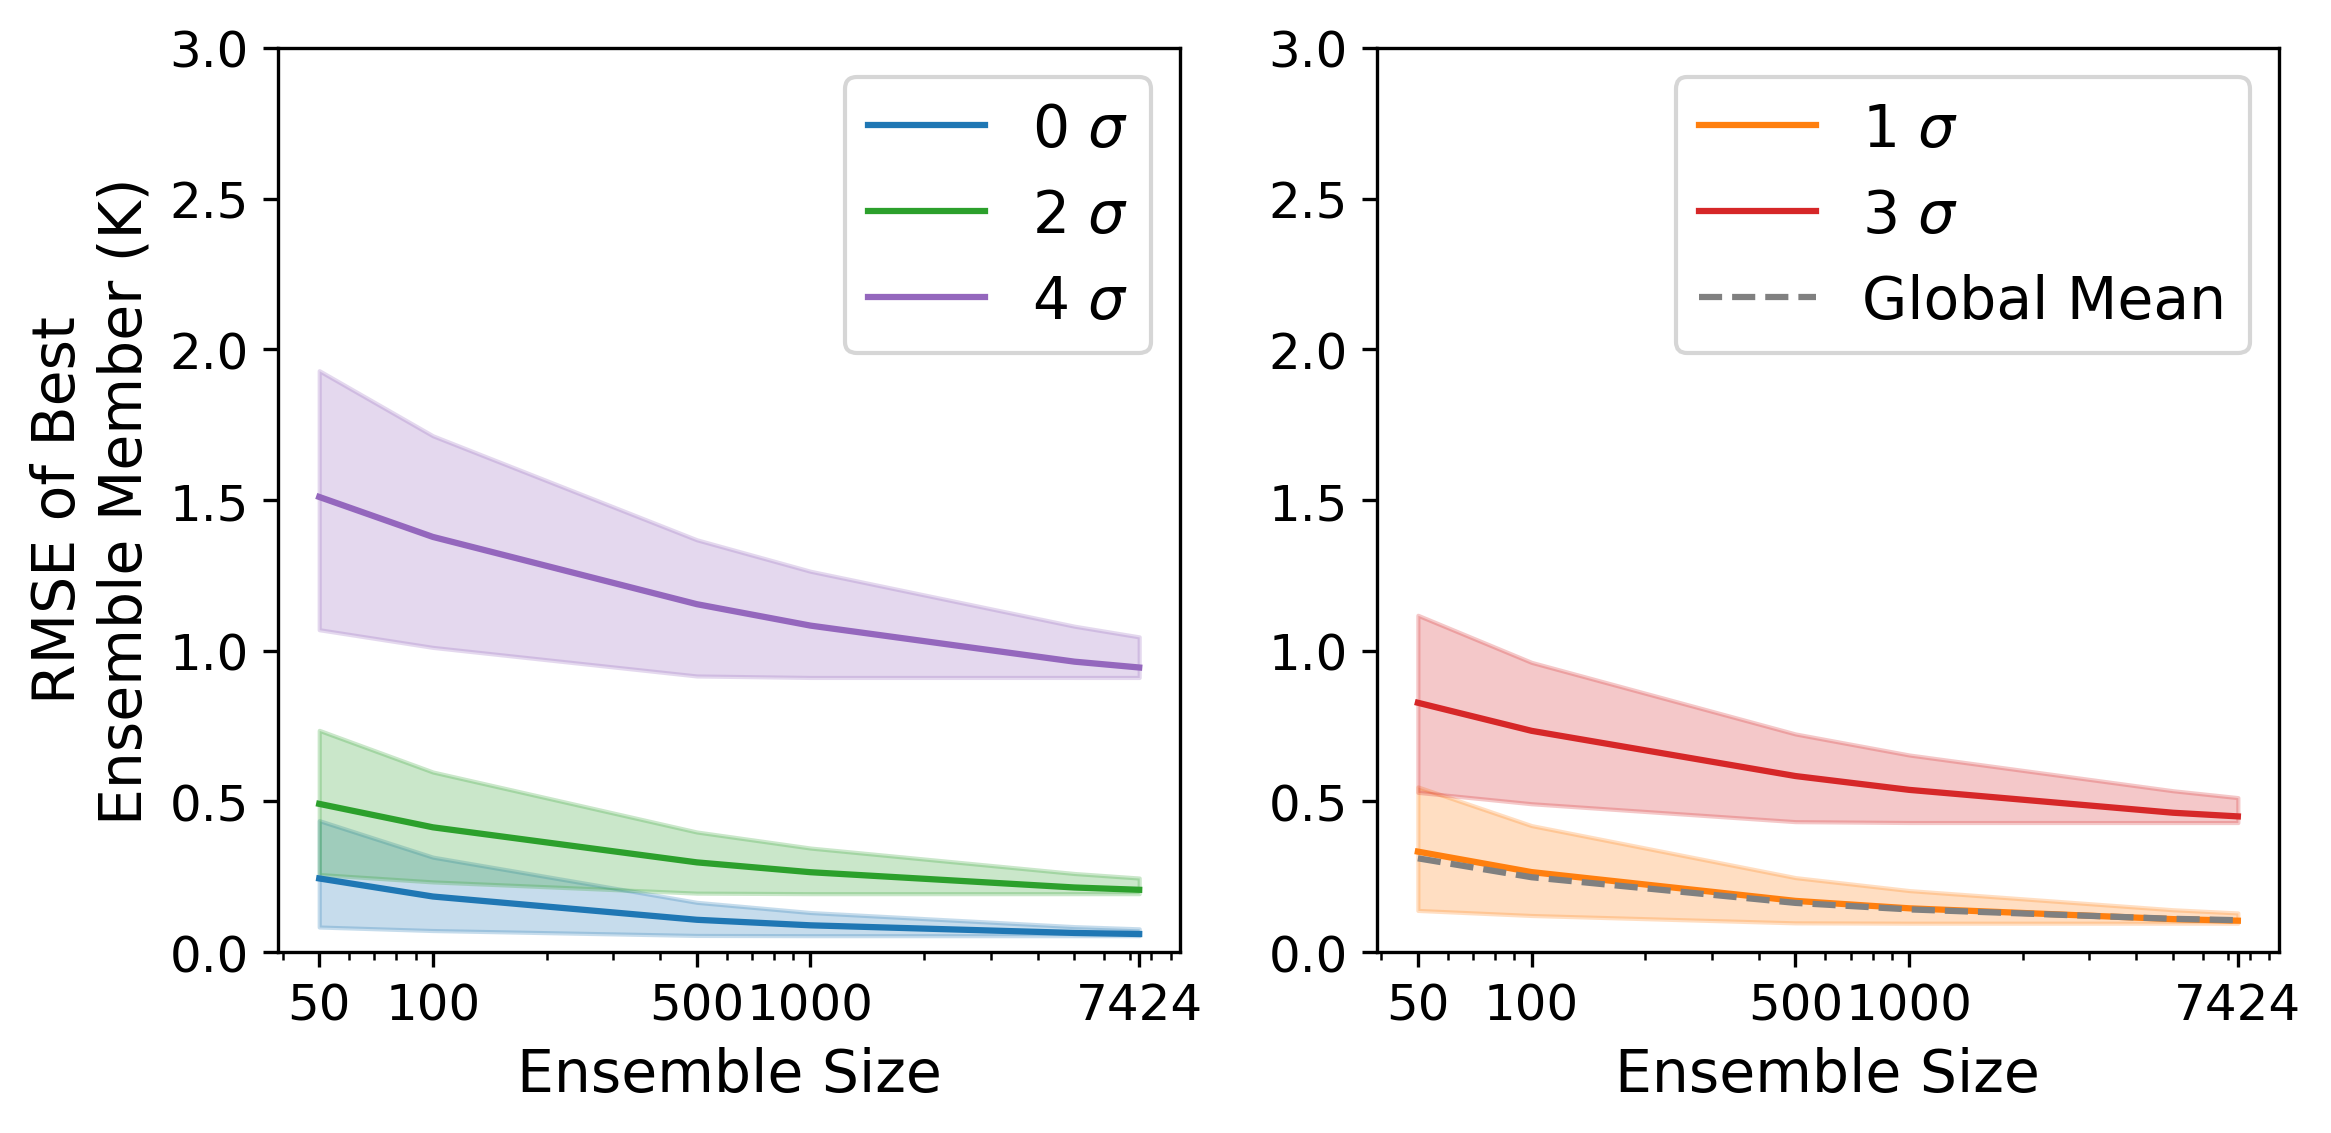

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

# Define sigma groups for each panel
left_panel_sigmas = [0, 2, 4]
right_panel_sigmas = [1, 3]

# Function to plot for a given panel and sigma values
def plot_sigma(ax, sigmas):
    for sigma in sigmas:
        subset = np.sqrt(xr.where(np.logical_and(np.abs(all_era5_zscore) > sigma, np.abs(all_era5_zscore) < sigma+1), all_min_mse, np.nan).weighted(weights).mean(('lat', 'lon')).mean(('initial_time', 'time')))
        subset_interval_low = np.sqrt(xr.where(np.logical_and(np.abs(all_era5_zscore) > sigma, np.abs(all_era5_zscore) < sigma+1), all_min_mse_interval.isel(interval=0), np.nan).weighted(weights).mean(('lat', 'lon')).mean(('initial_time', 'time')))
        subset_interval_high = np.sqrt(xr.where(np.logical_and(np.abs(all_era5_zscore) > sigma, np.abs(all_era5_zscore) < sigma+1), all_min_mse_interval.isel(interval=1), np.nan).weighted(weights).mean(('lat', 'lon')).mean(('initial_time', 'time')))

        ax.plot(subset['ensemble_size'], subset['Ensemble Minimum RMSE (K)'].values, label='{} $\sigma$'.format(sigma), color=f"C{sigma}")
        ax.fill_between(subset['ensemble_size'],
                        subset_interval_low['Ensemble Minimum RMSE (K)'].values,
                        subset_interval_high['Ensemble Minimum RMSE (K)'].values,
                        color=f"C{sigma}", alpha=0.25)
        subset.to_netcdf(f"/global/cfs/cdirs/m4416/www/hens/part_ii_figures/figure_7/min_mse_sigma{sigma}_lead4day.nc")
        subset_interval_low.to_netcdf(f"/global/cfs/cdirs/m4416/www/hens/part_ii_figures/figure_7/min_mse_sigma{sigma}_lowrange_lead4day.nc")
        subset_interval_high.to_netcdf(f"/global/cfs/cdirs/m4416/www/hens/part_ii_figures/figure_7/min_mse_sigma{sigma}_highrange_lead4day.nc")
        

    if 1 in sigmas:
        global_mean = np.sqrt(all_min_mse.weighted(weights).mean(('lat', 'lon')).mean(('initial_time', 'time')))
        ax.plot(global_mean['ensemble_size'], global_mean['Ensemble Minimum RMSE (K)'].values, label='Global Mean', color='gray', linestyle='dashed')
    else:
        ax.set_ylabel("RMSE of Best \nEnsemble Member (K)")
    ax.set_xscale("log")
    ax.set_xlabel("Ensemble Size")
    ax.set_xticks([50, 100, 500, 1000, 7424])
    ax.set_xticklabels([50, 100, 500, 1000, 7424])
    ax.set_ylim((0, 3))
    ax.legend()

# Plot for left panel
plot_sigma(axs[0], left_panel_sigmas)

# Plot for right panel
plot_sigma(axs[1], right_panel_sigmas)

plt.tight_layout()
plt.savefig("rmse_best_member_lead4day.pdf")
plt.show()
